# 📊 Brazilian E-Commerce: Customer Segmentation & RFM Analytics

### Overview
This project performs an in-depth customer behavior analysis using the **Brazilian E-Commerce Public Dataset by Olist**. By leveraging **RFM (Recency, Frequency, Monetary) Analysis** and **Unsupervised Machine Learning (K-Means Clustering)**, this notebook aims to transform transactional data into actionable marketing insights.

---

### 💡 Objective
To identify and categorize customer segments, enabling targeted marketing strategies, optimizing retention, and maximizing Customer Lifetime Value (CLV).

### 🛠 Methodology
1.  **Data Wrangling:** Merging 9 relational datasets (orders, items, customers, etc.) to build a master dataframe.
2.  **RFM Feature Engineering:** Quantifying customer behavior (Recency, Frequency, Monetary).
3.  **Data Preprocessing:** Handling skewed distributions and applying standard scaling.
4.  **Clustering:** Using the **Elbow Method** to determine optimal clusters and applying the **K-Means algorithm**.
5.  **Business Interpretation:** Profiling clusters into actionable segments (VIPs, Loyalists, Prospects, Lost).

---

### 📂 Dataset Structure
* **Source:** Olist E-Commerce Dataset (Kaggle)
* **Key Metrics:** Order history, purchase timestamps, and payment values.

---

### 📈 Interactive Dashboard
I have developed an interactive dashboard to visualize these customer segments. You can explore the data dynamically through the link below:

[**👉 Click here to view the Interactive RFM Dashboard**](https://datastudio.google.com/reporting/8c8cb95c-25e8-4552-8f91-49f76001d2c1)

*Note: Please ensure the dashboard is in "View" mode to interact with the filters.*

---
*Notebook by: Hangger Sukma Prima Darsono*

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hanggersukmapd/brazilian-e-commerce-public-dataset-by-olist/olist_customers_dataset.csv
/kaggle/input/datasets/hanggersukmapd/brazilian-e-commerce-public-dataset-by-olist/olist_sellers_dataset.csv
/kaggle/input/datasets/hanggersukmapd/brazilian-e-commerce-public-dataset-by-olist/olist_order_reviews_dataset.csv
/kaggle/input/datasets/hanggersukmapd/brazilian-e-commerce-public-dataset-by-olist/olist_order_items_dataset.csv
/kaggle/input/datasets/hanggersukmapd/brazilian-e-commerce-public-dataset-by-olist/olist_products_dataset.csv
/kaggle/input/datasets/hanggersukmapd/brazilian-e-commerce-public-dataset-by-olist/olist_geolocation_dataset.csv
/kaggle/input/datasets/hanggersukmapd/brazilian-e-commerce-public-dataset-by-olist/product_category_name_translation.csv
/kaggle/input/datasets/hanggersukmapd/brazilian-e-commerce-public-dataset-by-olist/olist_orders_dataset.csv
/kaggle/input/datasets/hanggersukmapd/brazilian-e-commerce-public-dataset-by-olist/olist_order_payme

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Set visualization style
sns.set_theme(style="whitegrid")

# =====================================================================
# PHASE 1: LOADING & RELATIONAL MERGING (KAGGLE PATHS)
# =====================================================================

print("Loading datasets...")
# Base path yang benar sesuai environment Anda
base_path = '/kaggle/input/datasets/hanggersukmapd/brazilian-e-commerce-public-dataset-by-olist/'

# Load tabel menggunakan base_path
df_orders = pd.read_csv(base_path + 'olist_orders_dataset.csv')
df_items = pd.read_csv(base_path + 'olist_order_items_dataset.csv')
df_customers = pd.read_csv(base_path + 'olist_customers_dataset.csv')

print(f"Orders shape: {df_orders.shape}")
print(f"Items shape: {df_items.shape}")
print(f"Customers shape: {df_customers.shape}")

print("\nMerging dataframes...")
# Step 1: Merge orders with customers
orders_with_cust = pd.merge(df_orders, df_customers, on='customer_id', how='inner')

# Step 2: Merge the result with order_items
master_df = pd.merge(orders_with_cust, df_items, on='order_id', how='inner')

print(f"Master Dataframe Shape after merging: {master_df.shape}")

# =====================================================================
# PHASE 2: DATA CLEANING & TYPE CONVERSION
# =====================================================================

print("\nCleaning data...")
# Convert datetime
master_df['order_purchase_timestamp'] = pd.to_datetime(master_df['order_purchase_timestamp'])

# Filter hanya pesanan yang berhasil dikirim (delivered)
master_df = master_df[master_df['order_status'] == 'delivered']

# Ambil kolom yang dibutuhkan saja untuk RFM
columns_to_keep = ['customer_unique_id', 'order_id', 'order_purchase_timestamp', 'price']
rfm_raw = master_df[columns_to_keep].copy()

print("\nMissing values in processed data:")
print(rfm_raw.isnull().sum())

print("\n--- Processed Raw RFM Data ---")
display(rfm_raw.head())

Loading datasets...
Orders shape: (99441, 8)
Items shape: (112650, 7)
Customers shape: (99441, 5)

Merging dataframes...
Master Dataframe Shape after merging: (112650, 18)

Cleaning data...

Missing values in processed data:
customer_unique_id          0
order_id                    0
order_purchase_timestamp    0
price                       0
dtype: int64

--- Processed Raw RFM Data ---


,customer_unique_id,order_id,order_purchase_timestamp,price
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,118.70
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,159.90
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,45.00
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,19.90


Calculating RFM metrics...

Final RFM Dataset Shape: (93358, 4)

--- Initial RFM Table ---


,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
2,0000f46a3911fa3c0805444483337064,537,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00


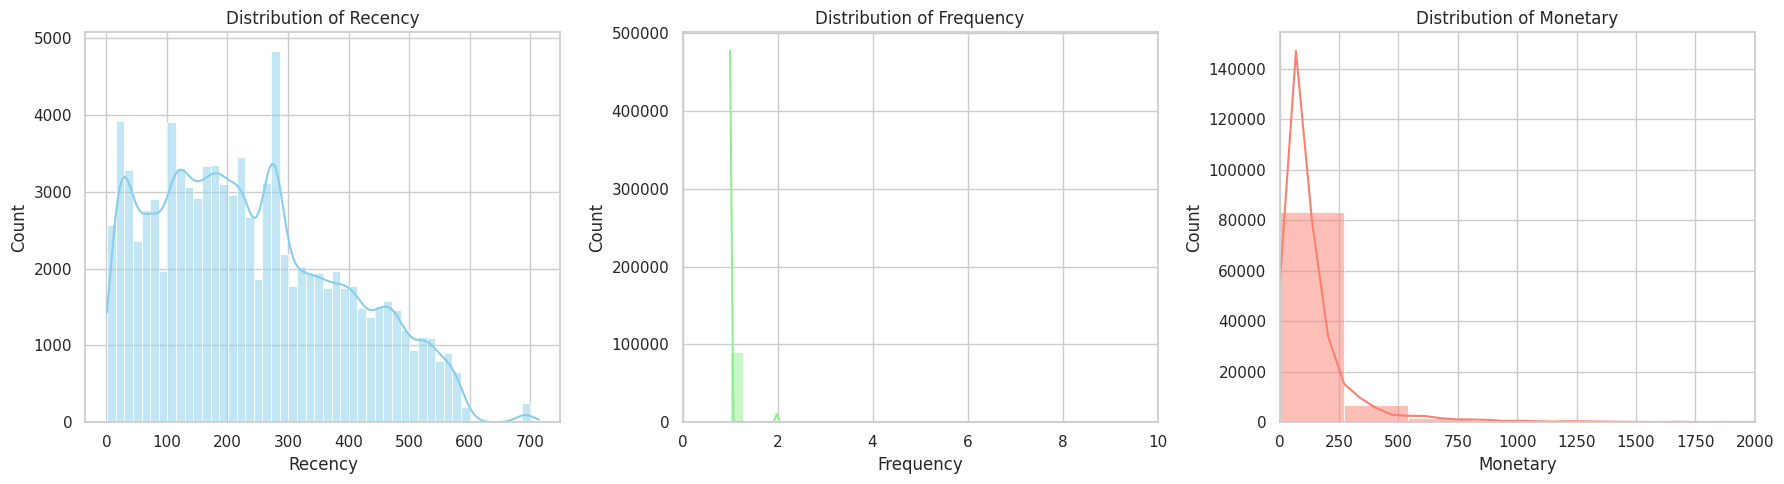


--- Descriptive Statistics ---


,Recency,Frequency,Monetary
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,141.621480
std,152.591453,0.209097,215.694014
min,1.000000,1.000000,0.850000
25%,114.000000,1.000000,47.650000
50%,219.000000,1.000000,89.730000
75%,346.000000,1.000000,154.737500
max,714.000000,15.000000,13440.000000


In [3]:
# =====================================================================
# PHASE 3: CALCULATING R-F-M METRICS
# =====================================================================

print("Calculating RFM metrics...")

# Tentukan tanggal 'sekarang' (1 hari setelah pesanan terakhir di dataset)
# Ini penting agar Recency tidak ada yang bernilai 0 atau negatif
latest_date = rfm_raw['order_purchase_timestamp'].max() + dt.timedelta(days=1)

# Lakukan agregasi per customer_unique_id
rfm = rfm_raw.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (latest_date - x.max()).days, # Recency
    'order_id': 'nunique',                                              # Frequency (harus nunique, bukan count!)
    'price': 'sum'                                                      # Monetary
}).reset_index()

# Rename kolom agar intuitif
rfm.rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'price': 'Monetary'
}, inplace=True)

print(f"\nFinal RFM Dataset Shape: {rfm.shape}")
print("\n--- Initial RFM Table ---")
display(rfm.head())

# =====================================================================
# PHASE 4: CHECKING FOR OUTLIERS & DISTRIBUTION
# =====================================================================

# Visualisasikan distribusi data RFM sebelum di-clustering
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Recency')

sns.histplot(rfm['Frequency'], bins=50, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Distribution of Frequency')

sns.histplot(rfm['Monetary'], bins=50, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Distribution of Monetary')

# Limit axis-x untuk Monetary dan Frequency agar outliers tidak merusak grafik
axes[1].set_xlim(0, 10) 
axes[2].set_xlim(0, 2000)

plt.tight_layout()
plt.show()

# Lihat statistik deskriptif
print("\n--- Descriptive Statistics ---")
display(rfm.describe())

Scaling RFM features for K-Means...
Scaling complete. Displaying first 5 rows of scaled data:
[[-0.82535715 -0.1598294  -0.05434338]
 [-0.80569671 -0.1598294  -0.56896404]
 [ 1.95987274 -0.1598294  -0.33668931]
 [ 0.54432061 -0.1598294  -0.53609322]
 [ 0.3280557  -0.1598294   0.17793134]]

Running the Elbow Method to find the optimal number of clusters (k)...


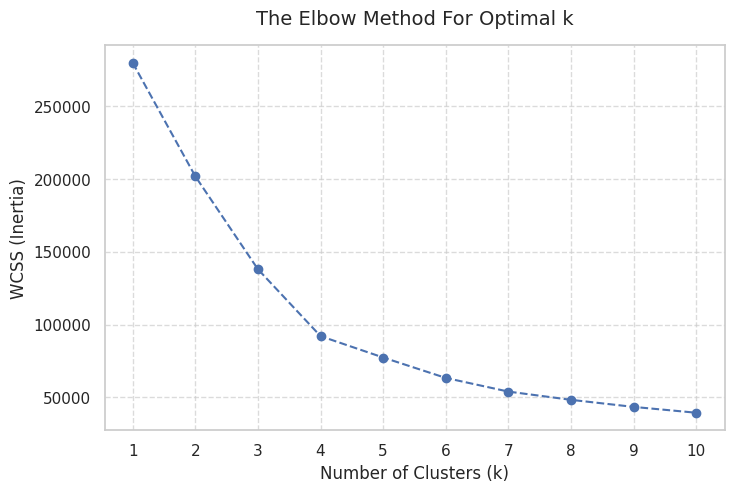

In [4]:
# =====================================================================
# PHASE 5: DATA SCALING & PREPROCESSING FOR K-MEANS
# =====================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Scaling RFM features for K-Means...")

# Extract only the numerical columns for clustering
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data to have mean=0 and variance=1
rfm_scaled = scaler.fit_transform(rfm_features)

print("Scaling complete. Displaying first 5 rows of scaled data:")
print(rfm_scaled[:5])

# =====================================================================
# PHASE 6: DETERMINING OPTIMAL CLUSTERS (THE ELBOW METHOD)
# =====================================================================

print("\nRunning the Elbow Method to find the optimal number of clusters (k)...")

# Initialize an empty list to store the Within-Cluster-Sum-of-Squares (WCSS)
wcss = []

# Test cluster numbers from 1 to 10
# (Using a subset or standard sampling can speed this up, but Olist is manageable)
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method For Optimal k', fontsize=14, pad=15)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [5]:
# =====================================================================
# PHASE 7: K-MEANS MODELING (K=4 BASED ON ELBOW METHOD)
# =====================================================================

print("Fitting K-Means model with 4 clusters...")
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
kmeans_final.fit(rfm_scaled)

# Assign cluster labels back to the original unscaled RFM dataframe
rfm['Cluster'] = kmeans_final.labels_

print("Clustering complete. Data sample with assigned clusters:")
display(rfm.head())

# =====================================================================
# PHASE 8: CLUSTER PROFILING & BUSINESS INTERPRETATION
# =====================================================================

print("\n--- Cluster Aggregation (Mean Values) ---")
# Aggregate data to understand the characteristics of each cluster
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

# Flatten MultiIndex columns for readability
cluster_profile.columns = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Customer_Count']
cluster_profile = cluster_profile.sort_values(by='Avg_Monetary', ascending=False)

display(cluster_profile)

Fitting K-Means model with 4 clusters...
Clustering complete. Data sample with assigned clusters:


,customer_unique_id,Recency,Frequency,Monetary,Cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,0
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,1
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,1



--- Cluster Aggregation (Mean Values) ---


,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Count
Cluster,,,,
2,237.68,1.01,1142.00,2189
3,220.42,2.11,243.16,2774
1,387.34,1.00,114.05,37649
0,128.07,1.00,113.37,50746


In [6]:
# =====================================================================
# PHASE 9: BUSINESS LABELING & EXPORTING FOR DASHBOARD
# =====================================================================

print("Assigning business labels to clusters...")

def assign_segment(cluster):
    if cluster == 2:
        return 'Big Spenders'
    elif cluster == 3:
        return 'Loyal Customers'
    elif cluster == 1:
        return 'Lost Customers'
    elif cluster == 0:
        return 'New/Recent Customers'
    else:
        return 'Unknown'

# Apply the labels
rfm['Customer_Segment'] = rfm['Cluster'].apply(assign_segment)

print("\n--- Final RFM Data with Business Segments ---")
display(rfm.head())

print("\nExporting dataset for visualization...")
# Save the final dataframe to a CSV file
rfm.to_csv('olist_rfm_segments.csv', index=False)
print("Success! File saved as 'olist_rfm_segments.csv' in your working directory.")

Assigning business labels to clusters...

--- Final RFM Data with Business Segments ---


,customer_unique_id,Recency,Frequency,Monetary,Cluster,Customer_Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,0,New/Recent Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,0,New/Recent Customers
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1,Lost Customers
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,1,Lost Customers
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,1,Lost Customers



Exporting dataset for visualization...
Success! File saved as 'olist_rfm_segments.csv' in your working directory.
